Enter number of revolutions:  2
Enter angular speed in rotations per minute:  5
Enter direction (0 for CW, 1 for CCW):  1


Running: 2.0 revolutions, 5.0 rot/min, CCW=True


Enter number of revolutions:  3
Enter angular speed in rotations per minute:  10
Enter direction (0 for CW, 1 for CCW):  0


Running: 3.0 revolutions, 10.0 rot/min, CCW=False


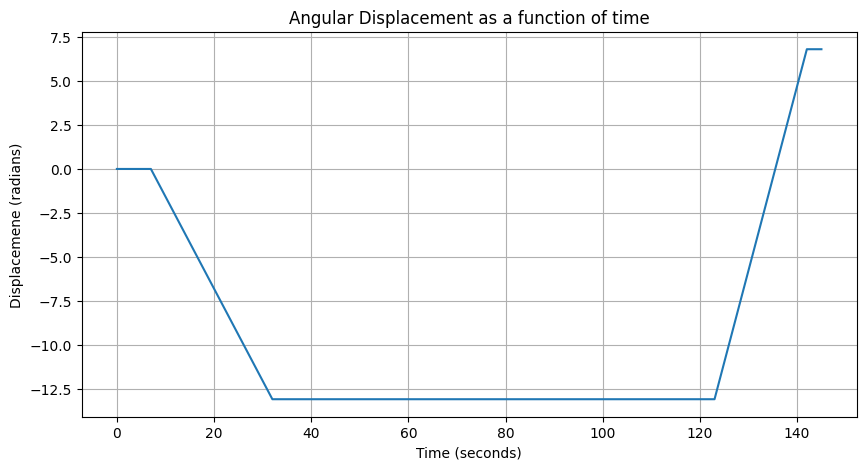

In [7]:
#Stepmotor, have motor pins be on GPIO 17,18,19,20.
import RPi.GPIO as GPIO
from RpiMotorLib.RpiMotorLib import BYJMotor
from matplotlib import pyplot as plt
import math
import threading
import time

GPIO.setmode(GPIO.BCM)

pins = [17,18,19,20]
GPIO.setup(pins,GPIO.OUT)
motor = BYJMotor("stepper", "28BYJ48")
x = []
y = []
displacement = 0.0
start_time = time.time()
running = True
accuracy = 1
angvel = 0

def bglogging():
    #Implements a variation of Eulers method
    global displacement, running
    while running:
        elapsed = time.time()-start_time
        x.append(elapsed)
        displacement += angvel*accuracy
        y.append(displacement)
        time.sleep(accuracy)

def get_valid_input(prompt, value_type=float):
    while True:
        try:
            return value_type(input(prompt))
        except ValueError:
            print(f"Invalid input. Please enter a {value_type.__name__}.")

def loop():
    global displacement, angvel
    while True:
        rev = get_valid_input("Enter number of revolutions: ")
        steps = rev * 512
        rpm = get_valid_input("Enter angular speed in rotations per minute: ", float)
        #need to correct speed conversion
        delay = 60/(rpm*4096)
        direction = -1
        while direction not in [0, 1]:
            direction = get_valid_input("Enter direction (0 for CW, 1 for CCW): ", int)
        
        is_ccw = (direction == 1)

        print(f"Running: {rev} revolutions, {rpm} rot/min, CCW={is_ccw}")
        
        pos = -1 if is_ccw else 1     

        angvel = pos*(rpm*2*math.pi)/60
        
        # Execute movement
        motor.motor_run(pins, delay, steps, is_ccw, False, "half", 0.05)
        angvel = 0

if __name__ == "__main__":
    try:
        log_thread = threading.Thread(target=bglogging, daemon=True)
        log_thread.start()
        loop()
    except KeyboardInterrupt:
        running = False
        plt.figure(figsize=(10,5))
        plt.plot(x,y)
        plt.title("Angular Displacement as a function of time")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Displacemene (radians)")
        plt.grid(True)
        plt.show()
        GPIO.output(pins, GPIO.LOW)
        GPIO.cleanup()